In [164]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [166]:
X, z = make_circles(n_samples=100, noise=0.1, random_state=1)

<Axes: >

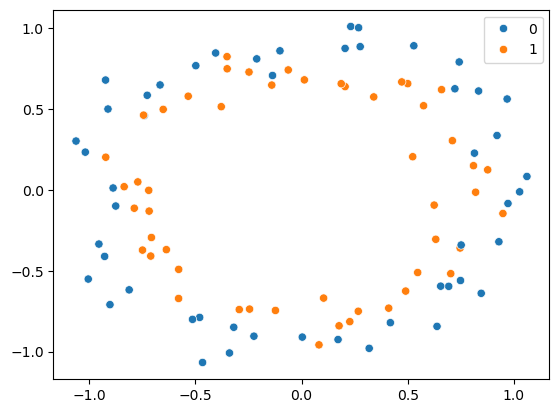

In [168]:
sns.scatterplot(x=X[:,0],y=X[:,1],hue=z)

In [170]:
X_train, X_test, y_train, y_test = train_test_split(X, z, test_size=0.20, random_state=2)

In [172]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

C:\Users\cipl\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [174]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [141]:
import time

In [176]:
start=time.time()
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, verbose=0)
end=time.time()
print(end-start)

225.2189977169037


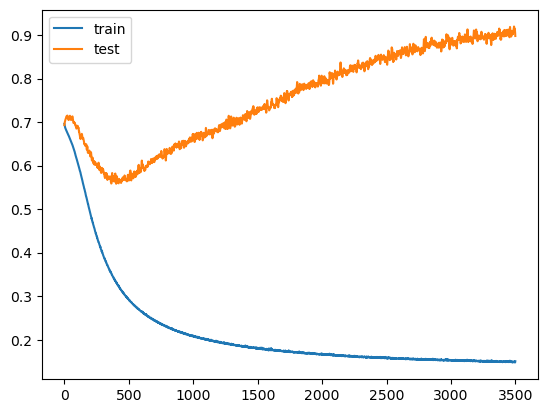

In [178]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

# Early Stopping

In [180]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [182]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

If you set patience=5: The model will keep training for up to 5 more epochs after it stops improving. If there’s still no improvement, it will stop traini

In [184]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode="auto",
)

In [186]:
start=time.time()
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, callbacks=callback)
end=time.time()
print(end-start)

Epoch 1/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - accuracy: 0.4602 - loss: 0.6939 - val_accuracy: 0.5500 - val_loss: 0.6955
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5133 - loss: 0.6912 - val_accuracy: 0.4500 - val_loss: 0.6961
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5320 - loss: 0.6899 - val_accuracy: 0.4500 - val_loss: 0.6970
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5688 - loss: 0.6882 - val_accuracy: 0.5000 - val_loss: 0.6989
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6031 - loss: 0.6868 - val_accuracy: 0.3500 - val_loss: 0.7019
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5758 - loss: 0.6835 - val_accuracy: 0.4000 - val_loss: 0.7049
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5602 - loss: 0.6844 - val_accuracy: 0.4000 - val_loss: 0.7073
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4992 - loss: 0.6871 - val_accuracy: 0.4000 - 

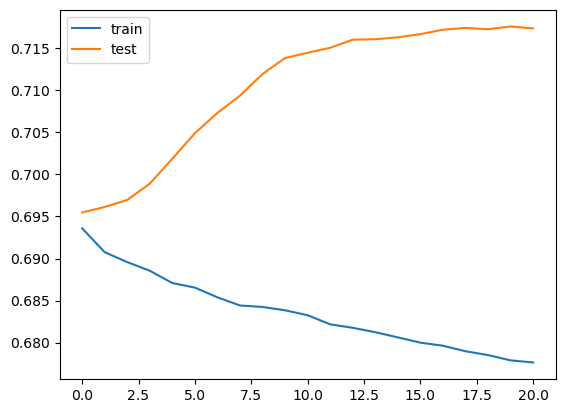

In [188]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

In [ ]:
# 3500 epochs
trainings loss= 0.2
testing losss 0.9

In [ ]:
# early stopping
trainings loss= 0.68
testing losss 0.71